【 練習 3：把 band 線變成 ARPES heatmap 】

對每一個 k，理論 band 能量為 E_theory(k)。使用 Lorentzian 模擬光譜寬度：

I(E,k) ∝ Γ / ((E−Etheory(k))² + Γ²)

建立一個能量軸 E，對每個 k 計算 intensity，並用 imshow() 畫出熱圖

再進一步乘上費米分佈函數

f(E,T)=1 / e^((E−μ)/kB​T+1) +1

觀察溫度改變時，圖譜如何改變


In [206]:
# 引入模組
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [207]:
# 一維 tight-binding (E(k)=−2tcos(ka))，固定每個k對應的能帶位置
## 參數設定
a = 1.0 # 晶格常數
t = 1.0 # eV
kB = 8.617e-5  # eV/K

Nk = 300 # 波數點
k = np.linspace(-np.pi/a, np.pi/a, Nk) # 波數範圍

E_k = -2*t*np.cos(k*a)

In [208]:
# 建立能量軸
NE = 400 # 能量軸的數值個數
E = np.linspace(-3, 3, NE) # eV

In [209]:
# 使用 Lorentzian 模擬光譜寬度
Gamma = 0.1 # 展寬參數，電子壽命（有限）為τ，則 Γ∼ℏ/​τ

I = np.zeros((NE, Nk))

# spectral function (描述電子態的能量分布)
for i in range(Nk):
    I[:, i] = Gamma / ((E - E_k[i])**2 + Gamma**2)

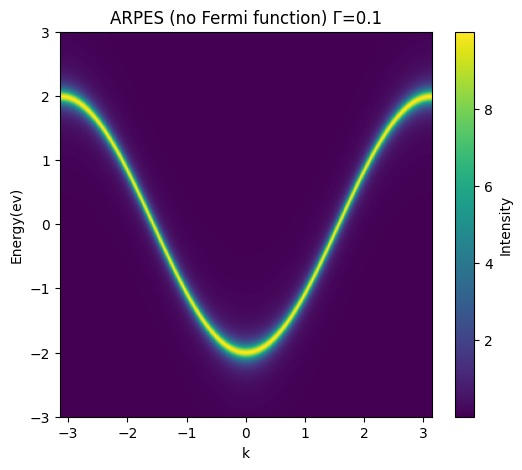

In [210]:
# 畫ㄍ熱圖 (2D data: use imshow)
plt.figure(figsize=(6,5))
plt.imshow(
    I,
    extent=[k.min(), k.max(), E.min(), E.max()],
    aspect='auto',
    origin='lower'
)
plt.xlabel("k")
plt.ylabel("Energy(ev)")
plt.title("ARPES (no Fermi function) Γ=0.1")
plt.colorbar(label="Intensity")
plt.show()

以上模擬為光譜函數的簡化版，可以看出一維tight-binding中，k=0時能量最小，k=±π/a時能量最大，而最低和最高能點的斜率為零，符合理論公式描述。由於沒有乘上費米函數，無法顯示特定溫度下哪些能態被電子佔據，因此可以看到整條曲線的intensity皆相同，且計算過程不包含溫度這一參數。而從不同Γ的圖可以看出，Γ越大，光譜寬度越寬，這是因為當電子壽命有限時，Γ∼ℏ/​τ，其中​τ微電子壽命，又量子力學中，​τ​𝜟E∼ℏ，因此當Γ越大，​τ越小，𝜟E就越大，光譜越寬。

In [211]:
# 加入費米分布（Fermi–Dirac distribution）：定義費米函數
def fermi(E, T, mu=0): # 選擇0為費米面，實際情況視材料變化
    return 1 / (np.exp((E - mu)/(kB*T)) + 1)

T_list = [300, 800, 5000, 10000]  # K


/var/folders/jv/t671b1nn6y15dk5xdwyl2pz80000gn/T/ipykernel_89046/684717653.py:25: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


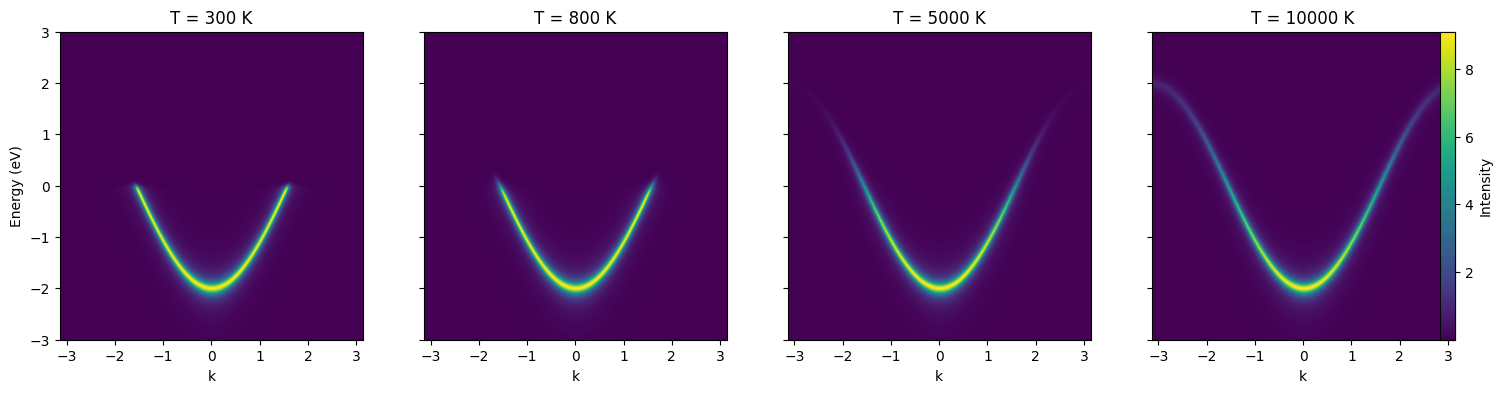

In [212]:
# 畫畫畫畫畫溫度改變ㄉ圖譜
fig, axes = plt.subplots(1, len(T_list), figsize=(18, 4), sharey=True)
gs = gridspec.GridSpec(1, len(T_list)+1, width_ratios=[1,1,1,1,0.05])
for i, T in enumerate(T_list):
    f = fermi(E, T)
    I_T = I * f[:, None]

    im = axes[i].imshow(
        I_T,
        extent=[k.min(), k.max(), E.min(), E.max()],
        aspect='auto',
        origin='lower'
    )

    axes[i].set_title(f"T = {T} K")
    axes[i].set_xlabel("k")

axes[0].set_ylabel("Energy (eV)")

# 共用colorbar（才能比較）
cbar_ax = fig.add_subplot(gs[0, -1])
# [left, bottom, width, height]（都是比例）
fig.colorbar(im, cax=cbar_ax, label="Intensity")

plt.tight_layout()
plt.show()